# Import libraries

In [1]:
# standard library
import os
import re
import sys
import subprocess
import importlib.util

# third-party
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from helper.io import load_data
from helper.geno import per_genotype_freq_per_human
from helper.pheno import make_pheno
from helper.plotting import show_biases
from helper.gwas import fit_line
from helper.effect_simulation import simulate_effects
from helper.pca import get_n_pcs

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data

In [2]:
raw_geno, humans = load_data()
snp_names = list(raw_geno.columns)

# Standardize

In [3]:
majaf, hetaf, minaf = per_genotype_freq_per_human(raw_geno, pop=humans["populations"])
majaf_tot = majaf.mean() 
hetaf_tot = hetaf.mean()
minaf_tot = minaf.mean()
geno_std = raw_geno - (majaf_tot-minaf_tot)
geno_std =geno_std/hetaf_tot**0.5
geno_corr_std = raw_geno - (majaf-minaf)
geno_corr_std = geno_corr_std/hetaf_tot**0.5

# Create population bias

In [4]:
pheno = make_pheno(humans)

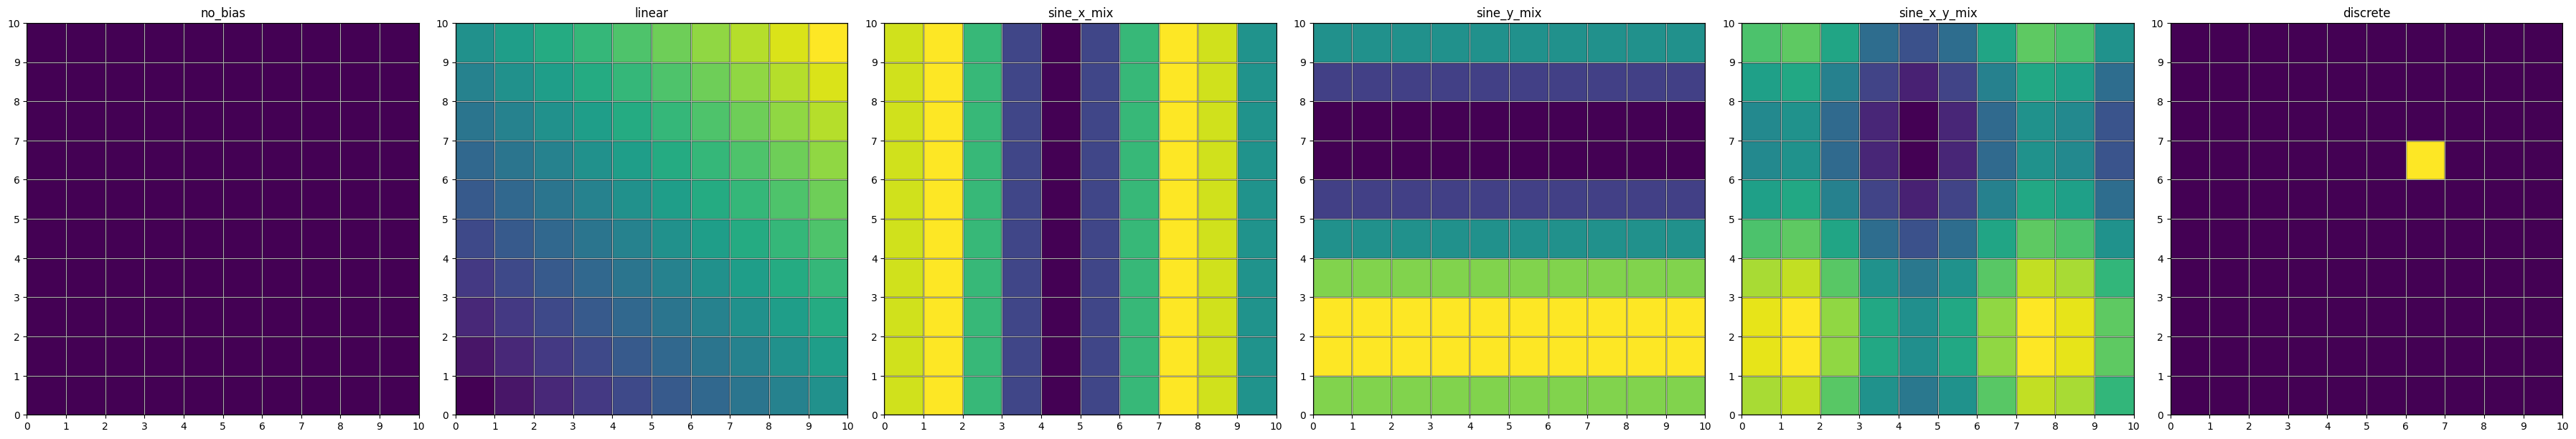

In [5]:
show_biases(pheno)

In [6]:
chosen_bias = "discrete"
#pheno[chosen_bias] = (pheno[chosen_bias] - pheno[chosen_bias].mean()) / pheno[chosen_bias].std()

In [7]:
qty_best = 4
qty_worst = 3
percentage_polygenic_noise = 20
effect_chosen_snp = 1
effect_most_corr_snps = 20
effect_least_corr_snps = 1
effect_polygenic_noise = 1

snps_simulated_meta_data = simulate_effects(
    geno_std, 
    pheno[chosen_bias],
    qty_best, 
    qty_worst, 
    percentage_polygenic_noise, 
    effect_chosen_snp, 
    effect_most_corr_snps, 
    effect_least_corr_snps, 
    effect_polygenic_noise)

In [8]:
perceived_slope = []

for idx, row in snps_simulated_meta_data.iterrows():
    snp = row.names
    beta = row.raw_betas
    pheno_temp = raw_geno[snp] * beta
    slope, intercept, neglogp = fit_line(geno_std[snp], pheno_temp, covs=None)
    perceived_slope.append(slope)
snps_simulated_meta_data['raw_betas_std'] = perceived_slope
perceived_slope = []
for idx, row in snps_simulated_meta_data.iterrows():
    snp = row.names
    beta = row.raw_betas
    pheno_temp = raw_geno[snp] * beta
    slope, intercept, neglogp = fit_line(geno_corr_std[snp], pheno_temp, covs=None)
    perceived_slope.append(slope)
snps_simulated_meta_data['raw_betas_std_corr'] = perceived_slope


In [9]:
snps_simulated_meta_data.categories.unique()

array(['nul', 'polygenic noise', 'most correlated', 'chosen snp',
       'least correlated'], dtype=object)

In [10]:
# create pheno

In [11]:
snps_for_causal = snps_simulated_meta_data[
    snps_simulated_meta_data["categories"] == "chosen snp"
]

snps_for_poly = snps_simulated_meta_data[
    snps_simulated_meta_data["categories"].isin(
        ["polygenic noise", "most correlated", "least correlated"]
    )
]

In [12]:
pheno['causal_effect'] = 0.0
for idx, row in snps_for_causal.iterrows():
    snp = row.names
    beta = row.raw_betas
    pheno_temp = raw_geno[snp] * beta
    pheno['causal_effect'] += pheno_temp

pheno['poly_effect'] = 0.0
for idx, row in snps_for_poly.iterrows():
    snp = row.names
    beta = row.raw_betas
    pheno_temp = raw_geno[snp] * beta
    pheno['poly_effect'] += pheno_temp

In [13]:
effect_pop = 1

In [14]:
pheno['population_effect'] = pheno[chosen_bias]*effect_pop

In [15]:
pheno['total'] = pheno['causal_effect'] + pheno["poly_effect"] + pheno['population_effect']

In [16]:
estimated_betas_std = []
for idx, row in snps_simulated_meta_data.iterrows():
    snp = row.names
    slope_estimated, intercept_causal, neglogp_causal = fit_line(geno_std[snp], pheno['total'])
    estimated_betas_std.append(slope_estimated)
snps_simulated_meta_data['estimated_betas_std'] = estimated_betas_std

In [17]:
estimated_betas_std = []
for idx, row in snps_simulated_meta_data.iterrows():
    snp = row.names
    slope_estimated, intercept_causal, neglogp_causal = fit_line(geno_corr_std[snp], pheno['total'])
    estimated_betas_std.append(slope_estimated)
snps_simulated_meta_data['estimated_betas_std_corr'] = estimated_betas_std

In [18]:
snps_simulated_meta_data

,names,categories,raw_betas,raw_betas_std,raw_betas_std_corr,estimated_betas_std,estimated_betas_std_corr
0,C_1_MAF_0.500,nul,0.000000,0.000000,0.000000,0.098927,0.108213
1,C_2_MAF_0.500,nul,0.000000,0.000000,0.000000,-0.252108,-0.088609
2,C_3_MAF_0.500,nul,0.000000,0.000000,0.000000,0.170300,0.125326
3,C_4_MAF_0.500,polygenic noise,0.000626,0.000240,0.000240,-0.245052,-0.063467
4,C_5_MAF_0.500,nul,0.000000,0.000000,0.000000,0.234840,0.083073
...,...,...,...,...,...,...,...
7995,VR_7996_MAF_0.042,nul,0.000000,0.000000,0.000000,-0.111194,-0.113039
7996,VR_7997_MAF_0.042,nul,0.000000,0.000000,0.000000,-0.078353,-0.076608
7997,VR_7998_MAF_0.042,polygenic noise,0.000626,0.000176,0.000176,-0.119059,-0.165024
7998,VR_7999_MAF_0.042,polygenic noise,0.000626,0.000176,0.000176,0.008283,-0.073238


In [19]:
# fit line
chosen_snp = list(snps_for_causal.names)[0]

In [20]:
slope_causal, intercept_causal, neglogp_causal = fit_line(geno_std[chosen_snp], pheno['causal_effect'])
slope_poly, intercept_poly, neglogp_poly = fit_line(geno_std[chosen_snp], pheno['poly_effect'])
slope_pop, intercept_pop, neglogp_pop = fit_line(geno_std[chosen_snp], pheno['population_effect'])
slope_total, intercept_total, neglogp_total = fit_line(geno_std[chosen_snp], pheno['total'])

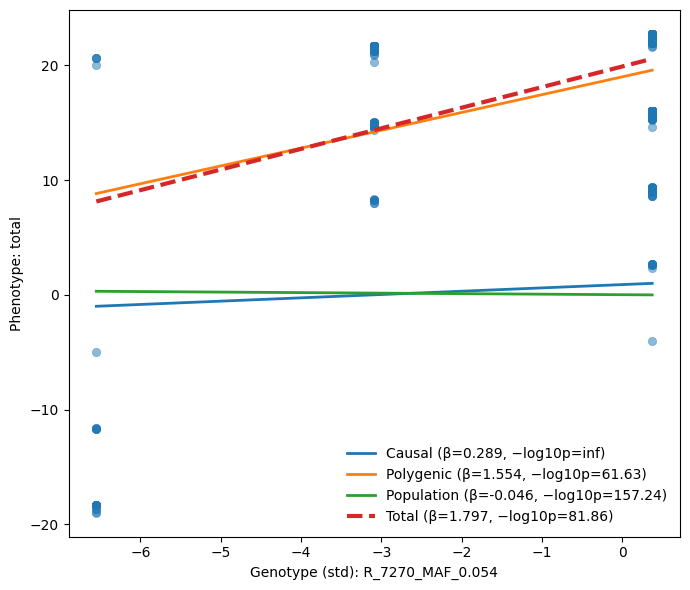

In [21]:

# Prepare data
x = geno_std[chosen_snp].values
df_plot = pd.DataFrame({
    "x": x,
    "total": pheno["total"],
})

# Base scatter plot
plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=df_plot,
    x="x",
    y="total",
    alpha=0.5,
    edgecolor=None
)

# X range for fitted lines
x_line = np.linspace(x.min(), x.max(), 200)

# Plot fitted lines
plt.plot(
    x_line,
    slope_causal * x_line + intercept_causal,
    label=f"Causal (β={slope_causal:.3f}, −log10p={neglogp_causal:.2f})",
    linewidth=2
)

plt.plot(
    x_line,
    slope_poly * x_line + intercept_poly,
    label=f"Polygenic (β={slope_poly:.3f}, −log10p={neglogp_poly:.2f})",
    linewidth=2
)

plt.plot(
    x_line,
    slope_pop * x_line + intercept_pop,
    label=f"Population (β={slope_pop:.3f}, −log10p={neglogp_pop:.2f})",
    linewidth=2
)

plt.plot(
    x_line,
    slope_total * x_line + intercept_total,
    label=f"Total (β={slope_total:.3f}, −log10p={neglogp_total:.2f})",
    linewidth=3,
    linestyle="--"
)

# Labels & styling
plt.xlabel(f"Genotype (std): {chosen_snp}")
plt.ylabel("Phenotype: total")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


In [22]:
# estimate betas_poly

In [68]:
import numpy as np
import pandas as pd

def PC_distance_to_snp(geno_std, chosen_snp, n_pcs=25):
    snps_pcs = get_n_pcs(geno_std.T, n_pcs)  # index = SNPs, columns = PCs

    X = snps_pcs.to_numpy(dtype=float)
    i = snps_pcs.index.get_loc(chosen_snp)

    diff = X - X[i]
    dists = np.sqrt(np.sum(diff * diff, axis=1))

    dist_df = pd.DataFrame({"snp": snps_pcs.index, "distance": dists})
    dist_df = dist_df[dist_df["snp"] != chosen_snp].sort_values("distance", ascending=False)

    dmin, dmax = dist_df["distance"].min(), dist_df["distance"].max()
    dist_df["proximity"] = 1.0 - (dist_df["distance"] - dmin) / (dmax - dmin)

    return dist_df

In [69]:
import numpy as np
import pandas as pd

def pearson_distance_to_snp(geno_std, chosen_snp):
    X = geno_std.to_numpy(dtype=float)                 # (n_samples, n_snps)
    cols = geno_std.columns
    i = cols.get_loc(chosen_snp)

    x = X[:, i]
    n = X.shape[0]

    # correlation of chosen SNP with every SNP (since standardized)
    r = (X.T @ x) / (n - 1)                            # (n_snps,)

    dist = 1.0 - r                                     # Pearson distance

    dist_df = pd.DataFrame({"snp": cols, "distance": dist})
    dist_df = dist_df[dist_df["snp"] != chosen_snp].sort_values("distance", ascending=False)

    dmin, dmax = dist_df["distance"].min(), dist_df["distance"].max()
    dist_df["proximity"] = 1.0 - (dist_df["distance"] - dmin) / (dmax - dmin)

    return dist_df

In [71]:
pc_df = PC_distance_to_snp(geno_std, chosen_snp, n_pcs=25)
pear_df = pearson_distance_to_snp(geno_std, chosen_snp)

In [72]:
cmp_df = pc_df.merge(
    pear_df,
    on="snp",
    suffixes=("_pc", "_pearson")
)


In [73]:
cmp_df

,snp,distance_pc,proximity_pc,distance_pearson,proximity_pearson
0,C_1130_MAF_0.357,70.444514,0.000000,1.078336,0.319347
1,C_208_MAF_0.474,69.027922,0.021514,1.152093,0.229038
2,C_1156_MAF_0.355,68.182750,0.034349,1.071096,0.328212
3,C_1050_MAF_0.368,68.110841,0.035441,1.093559,0.300708
4,C_1070_MAF_0.365,67.660016,0.042288,1.082716,0.313985
...,...,...,...,...,...
7994,R_6225_MAF_0.063,5.836927,0.981195,0.658993,0.832802
7995,R_6191_MAF_0.064,5.798228,0.981783,0.713131,0.766513
7996,R_6885_MAF_0.057,5.615919,0.984551,0.695734,0.787815
7997,R_6350_MAF_0.062,5.580954,0.985082,0.656919,0.835341


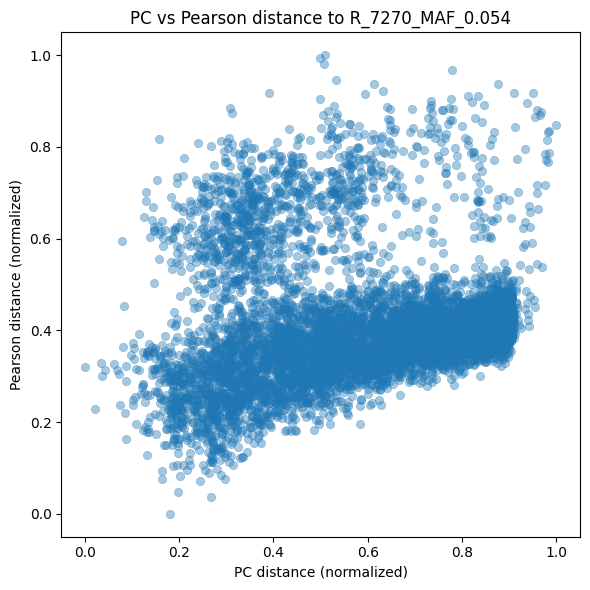

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
sns.scatterplot(
    data=cmp_df,
    x="proximity_pc",
    y="proximity_pearson",
    alpha=0.4,
    edgecolor=None
)

plt.xlabel("PC distance (normalized)")
plt.ylabel("Pearson distance (normalized)")
plt.title(f"PC vs Pearson distance to {chosen_snp}")
plt.tight_layout()
plt.show()


In [75]:
# corrected

In [76]:
slope_causal, intercept_causal, neglogp_causal = fit_line(geno_corr_std[chosen_snp], pheno['causal_effect'])
slope_poly, intercept_poly, neglogp_poly = fit_line(geno_corr_std[chosen_snp], pheno['poly_effect'])
slope_pop, intercept_pop, neglogp_pop = fit_line(geno_corr_std[chosen_snp], pheno['population_effect'])
slope_total, intercept_total, neglogp_total = fit_line(geno_corr_std[chosen_snp], pheno['total'])

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare data
x = geno_corr_std[chosen_snp].values
df_plot = pd.DataFrame({
    "x": x,
    "total": pheno["total"],
})

# Base scatter plot
plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=df_plot,
    x="x",
    y="total",
    alpha=0.5,
    edgecolor=None
)

# X range for fitted lines
x_line = np.linspace(x.min(), x.max(), 200)

# Plot fitted lines
plt.plot(
    x_line,
    slope_causal * x_line + intercept_causal,
    label=f"Causal (β={slope_causal:.3f}, −log10p={neglogp_causal:.2f})",
    linewidth=2
)

plt.plot(
    x_line,
    slope_poly * x_line + intercept_poly,
    label=f"Polygenic (β={slope_poly:.3f}, −log10p={neglogp_poly:.2f})",
    linewidth=2
)

plt.plot(
    x_line,
    slope_pop * x_line + intercept_pop,
    label=f"Population (β={slope_pop:.3f}, −log10p={neglogp_pop:.2f})",
    linewidth=2
)

plt.plot(
    x_line,
    slope_total * x_line + intercept_total,
    label=f"Total (β={slope_total:.3f}, −log10p={neglogp_total:.2f})",
    linewidth=3,
    linestyle="--"
)

# Labels & styling
plt.xlabel(f"Genotype (std): {chosen_snp}")
plt.ylabel("Phenotype: total")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


NameError: name 'geno_corr_std' is not defined